In [136]:
import pandas as pd
import numpy as np
import plotly.express as px
import datetime as dt

In [137]:
file = "C:/Users/Asus/OneDrive/Desktop/GymIQ/sample_data.csv"

data = pd.read_csv(file)

In [138]:
data.head()

,Date,Exercise,Weight,Reps,Sets,RestSeconds
0,2024-01-01,Squat,80.0,8,4,120
1,2024-01-01,Bench Press,60.0,8,4,120
2,2024-01-03,Deadlift,100.0,5,3,180
3,2024-01-03,Overhead Press,40.0,8,3,90
4,2024-01-05,Squat,82.5,8,4,120


In [139]:
gym_data = data
gym_data['Total Volume'] = data['Weight'] * data['Reps'] * data['Sets'] 

In [140]:
gym_data.head()

,Date,Exercise,Weight,Reps,Sets,RestSeconds,Total Volume
0,2024-01-01,Squat,80.0,8,4,120,2560.0
1,2024-01-01,Bench Press,60.0,8,4,120,1920.0
2,2024-01-03,Deadlift,100.0,5,3,180,1500.0
3,2024-01-03,Overhead Press,40.0,8,3,90,960.0
4,2024-01-05,Squat,82.5,8,4,120,2640.0


In [141]:
gym_data['Date'] = pd.to_datetime(gym_data['Date'], format = "%Y-%m-%d")

In [142]:
gym_data['Date'] = gym_data['Date'].sort_values()

In [143]:
gym_data['Session ID'] = gym_data['Date'].factorize()[0] + 1

In [144]:
gym_data = gym_data.set_index('Date')

In [145]:
gym_data.resample('W')['Session ID'].nunique()

Date
2024-01-07    3
2024-01-14    3
2024-01-21    3
2024-01-28    3
2024-02-04    3
2024-02-11    3
2024-02-18    3
2024-02-25    2
Freq: W-SUN, Name: Session ID, dtype: int64

In [146]:
# gym_data = gym_data.dropna()

# Solid Analytics

In [147]:
gym_data['Week Number'] = gym_data.index.isocalendar().week
gym_data.head()

,Exercise,Weight,Reps,Sets,RestSeconds,Total Volume,Session ID,Week Number
Date,,,,,,,,
2024-01-01,Squat,80.0,8,4,120,2560.0,1,1
2024-01-01,Bench Press,60.0,8,4,120,1920.0,1,1
2024-01-03,Deadlift,100.0,5,3,180,1500.0,2,1
2024-01-03,Overhead Press,40.0,8,3,90,960.0,2,1
2024-01-05,Squat,82.5,8,4,120,2640.0,3,1


In [148]:
#Weekly workload
weekly_volume = gym_data.resample('W-SUN')['Total Volume'].sum()
weekly_volume = weekly_volume.reset_index()

In [149]:
weekly_volume['Rolling Average'] = (
    weekly_volume['Total Volume']
    .rolling(2)
    .mean()
)

In [150]:
weekly_volume

,Date,Total Volume,Rolling Average
0,2024-01-07,11580.0,NaN
1,2024-01-14,11435.0,11507.5
2,2024-01-21,11870.0,11652.5
3,2024-01-28,11665.0,11767.5
4,2024-02-04,12080.0,11872.5
5,2024-02-11,11815.0,11947.5
6,2024-02-18,11530.0,11672.5
7,2024-02-25,6660.0,9095.0


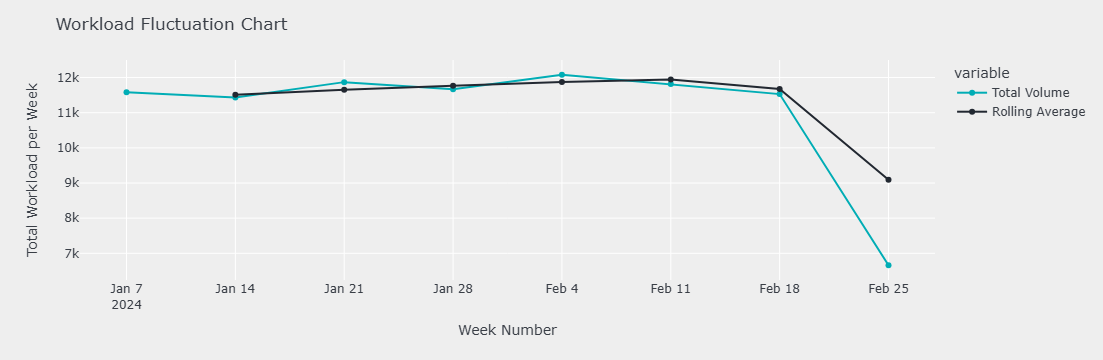

In [151]:
plot_title = 'Workload Fluctuation Chart'

workload_data = px.line(
    weekly_volume,
    x = 'Date',
    y = ['Total Volume', 'Rolling Average'],
    markers = True,
    color_discrete_sequence=['#00ADB5','#222831']
)

workload_data.update_layout(
    xaxis_title="Week Number",
    yaxis_title="Total Workload per Week",
    title = plot_title,
    font_color = '#393E46',
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    hovermode = 'x unified'
)

In [152]:
#Growth Rate
weekly_volume['Growth Rate'] = weekly_volume['Total Volume'].pct_change()*100

In [153]:
weekly_volume['Growth Rate'] = weekly_volume['Growth Rate'].fillna(0)
weekly_volume

,Date,Total Volume,Rolling Average,Growth Rate
0,2024-01-07,11580.0,NaN,0.000000
1,2024-01-14,11435.0,11507.5,-1.252159
2,2024-01-21,11870.0,11652.5,3.804110
3,2024-01-28,11665.0,11767.5,-1.727043
4,2024-02-04,12080.0,11872.5,3.557651
5,2024-02-11,11815.0,11947.5,-2.193709
6,2024-02-18,11530.0,11672.5,-2.412188
7,2024-02-25,6660.0,9095.0,-42.237641


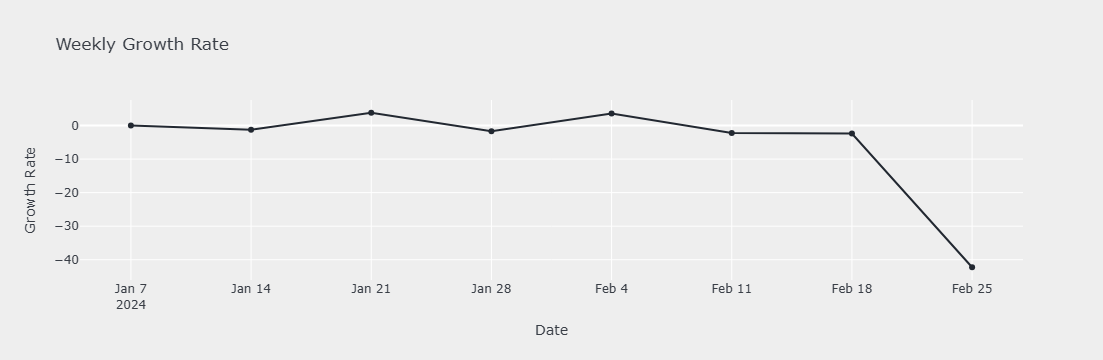

In [154]:
weekly_growth_rate = px.line(
    weekly_volume,
    x='Date',
    y= 'Growth Rate',
    markers=True,
    title='Weekly Growth Rate',
    color_discrete_sequence=['#222831']
)

weekly_growth_rate.update_layout(
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    hovermode = 'x unified',
    font_color = '#393E46'
)

weekly_growth_rate.show()

In [155]:
#Average weight per week

gym_data.head()
weekly_strength = gym_data.resample('W-SUN')['Weight'].mean().reset_index()
weekly_strength

,Date,Weight
0,2024-01-07,70.833333
1,2024-01-14,73.750000
2,2024-01-21,76.666667
3,2024-01-28,79.583333
4,2024-02-04,82.500000
5,2024-02-11,85.416667
6,2024-02-18,88.333333
7,2024-02-25,93.125000


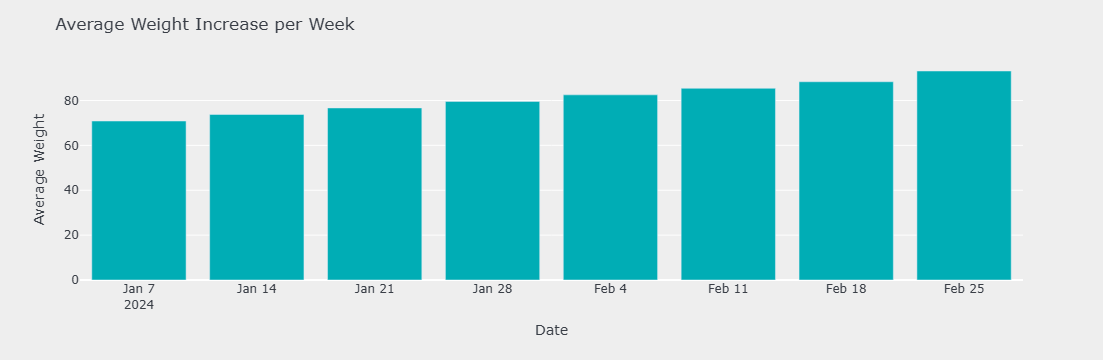

In [156]:
weight_growth_rate = px.bar(
    x = weekly_strength['Date'],
    y = weekly_strength['Weight'],
    labels = {'x': 'Date', 'y': 'Average Weight'},
    color_discrete_sequence = ['#00ADB5']
)

weight_growth_rate.update_layout(
    title = 'Average Weight Increase per Week',
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)

weight_growth_rate.show()

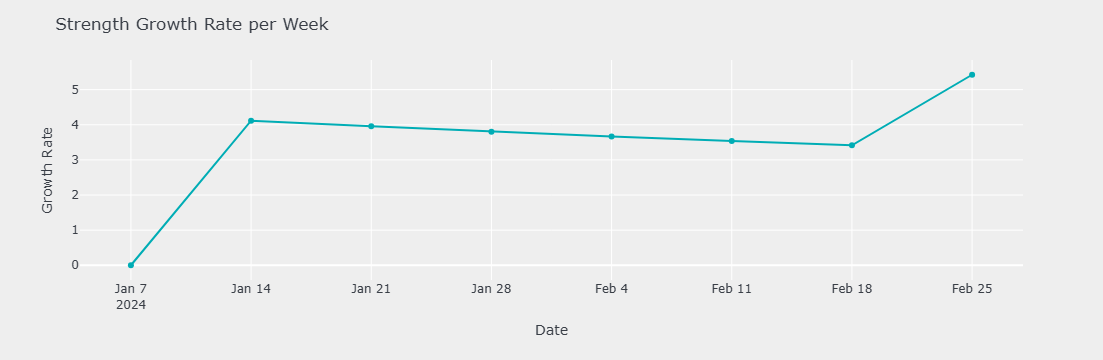

In [157]:
#Weekly growth rate strength

weekly_strength['Growth Rate'] = weekly_strength['Weight'].pct_change() * 100
weekly_strength['Growth Rate'] = weekly_strength['Growth Rate'].fillna(0)

weight_growth_rate = px.line(
    weekly_strength,
    x = weekly_strength['Date'],
    y = weekly_strength['Growth Rate'],
    color_discrete_sequence = ['#00ADB5'],
    markers = True
)

weight_growth_rate.update_layout(
    title = 'Strength Growth Rate per Week',
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)

In [158]:
training_load =  pd.merge(weekly_volume, weekly_strength, on = 'Date', how = 'inner')

In [159]:
training_load['Volume Z'] = (
    training_load['Total Volume'] - training_load['Total Volume'].mean()
) / training_load['Total Volume'].std()

training_load['Weight Z'] = (
    training_load['Weight'] - training_load['Weight'].mean()
) / training_load['Weight'].std()

In [160]:
training_load[['Volume Z', 'Weight Z']].describe()

,Volume Z,Weight Z
count,8.000000,8.000000e+00
mean,0.000000,1.221245e-15
std,1.000000,1.000000e+00
min,-2.458382,-1.383779e+00
25%,0.237459,-7.074183e-01
50%,0.302126,-3.105739e-02
75%,0.416858,6.453035e-01
max,0.556621,1.570123e+00


In [161]:
training_load['Training Index'] = (training_load['Volume Z'] + training_load['Weight Z'])

In [162]:
training_load["Week_Label"] = training_load["Date"].dt.strftime("%b %d")

In [163]:
def classify(row):
    if (row['Volume Z'] > 0) and (row['Weight Z'] > 0):
        return 'Overload'
    elif (row['Volume Z'] > 0) and (row['Weight Z'] <= 0):
        return 'Hypertrophy'
    elif (row['Volume Z'] <= 0) and (row['Weight Z'] > 0):
        return 'Strength'
    else:
        return 'Deload'

training_load['PhaseTag'] = training_load.apply(classify, axis = 1)

In [164]:
min_val = training_load['Training Index'].min()
training_load['Size Metric'] = training_load['Training Index'] - min_val

In [165]:
ti = training_load['Training Index']

training_load['Size Metric'] = (
    (ti - ti.min()) / (ti.max() - ti.min())
) * 40 + 10

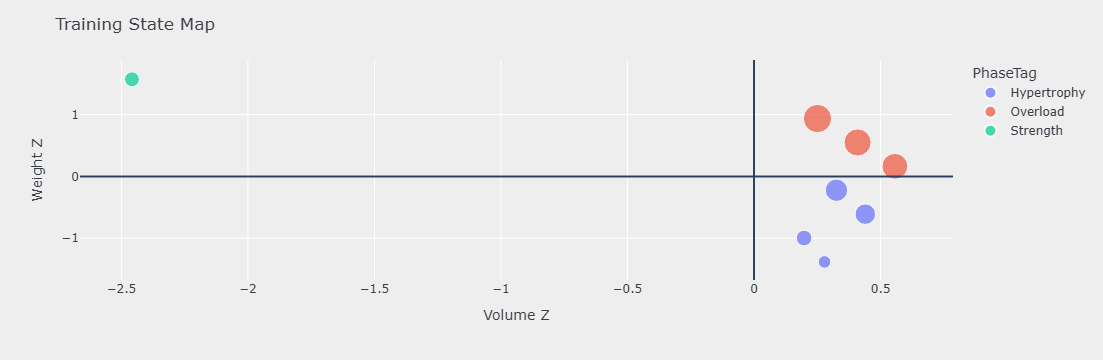

In [166]:
plot_title = 'Training State Map'

training_index = px.scatter(
    training_load,
    x = 'Volume Z',
    y = 'Weight Z',
    color = 'PhaseTag',
    size = 'Size Metric'
)

training_index.add_hline(y=0)
training_index.add_vline(x=0)

training_index.update_layout(
    title = plot_title,
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46',
)

# Fatigue and Load Management Logic

In [167]:
#Acute Chronic Workload Ratio
fatigue_data = weekly_volume['Total Volume'].reset_index()

In [168]:
fatigue_data

,index,Total Volume
0,0,11580.0
1,1,11435.0
2,2,11870.0
3,3,11665.0
4,4,12080.0
5,5,11815.0
6,6,11530.0
7,7,6660.0


In [169]:
fatigue_data['Chronic Load'] = (
    weekly_volume['Total Volume']
    .rolling(4)
    .mean()
)

# fatigue_data['Total Volume'].ewm(span=4, adjust=False).mean()

In [170]:
fatigue_data = fatigue_data.drop('index', axis = 1)

In [171]:
fatigue_data['ACWR'] = (fatigue_data['Total Volume'] / fatigue_data['Chronic Load'])

In [172]:
fatigue_data['ACWR'] = fatigue_data['ACWR'].fillna(0)

In [173]:
fatigue_data

,Total Volume,Chronic Load,ACWR
0,11580.0,NaN,0.000000
1,11435.0,NaN,0.000000
2,11870.0,NaN,0.000000
3,11665.0,11637.50,1.002363
4,12080.0,11762.50,1.026993
5,11815.0,11857.50,0.996416
6,11530.0,11772.50,0.979401
7,6660.0,10521.25,0.633005


In [174]:
def Interpretation(row):
    if (0.8 <= row['ACWR'] <= 1.3):
        return 'Safe-Stimulus'
    elif (row['ACWR'] >= 1.5):
        return 'Spike (Injury Risk)'
    else:
        return 'Under-Stimulus'

fatigue_data['Interpretation'] = fatigue_data.apply(Interpretation, axis = 1)

In [175]:
fatigue_data

,Total Volume,Chronic Load,ACWR,Interpretation
0,11580.0,NaN,0.000000,Under-Stimulus
1,11435.0,NaN,0.000000,Under-Stimulus
2,11870.0,NaN,0.000000,Under-Stimulus
3,11665.0,11637.50,1.002363,Safe-Stimulus
4,12080.0,11762.50,1.026993,Safe-Stimulus
5,11815.0,11857.50,0.996416,Safe-Stimulus
6,11530.0,11772.50,0.979401,Safe-Stimulus
7,6660.0,10521.25,0.633005,Under-Stimulus


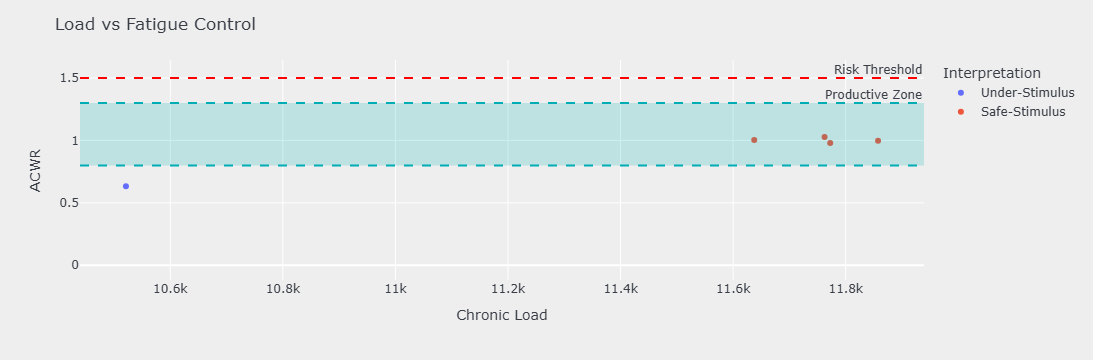

In [193]:
plot_title = 'Load vs Fatigue Control'

fatigue_ratio = px.scatter(
    fatigue_data,
    x = 'Chronic Load',
    y = 'ACWR',
    color = 'Interpretation'
)

fatigue_ratio.add_hline(
    y=1.5, 
    line_width=2, 
    line_dash="dash", 
    line_color="red", 
    annotation_text="Risk Threshold",
    
)

fatigue_ratio.add_hline(
    y=0.8, 
    line_width=2, 
    line_dash="dash", 
    line_color="#00ADB5"
)

fatigue_ratio.add_hline(
    y=1.3, 
    line_width=2, 
    line_dash="dash", 
    line_color="#00ADB5", 
    annotation_text="Productive Zone"
)

fatigue_ratio.add_hrect(
    y0=0.8, y1=1.3,
    fillcolor="#00ADB5",
    opacity=0.2,
    line_width=0
)

fatigue_ratio.update_layout(
    title = plot_title,
    plot_bgcolor = '#EEEEEE',
    paper_bgcolor = '#EEEEEE',
    font_color = '#393E46'
)